<a href="https://colab.research.google.com/github/Stav788/archaeo-ner-greek/blob/dev/notebooks/gliner2_training%20stav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning GLiNER2 for Archaeological Named Entity Recognition


### Colab Configuration Requirements
To run this notebook on Google Colab, add the following secrets to your environment (Key icon in the left sidebar):
#### 1. Repository Access
* **`GITHUB_TOKEN`**: Required for cloning private source code.
* **Obtain**: [GitHub Settings](https://github.com/settings/tokens) > Developer Settings > Personal access tokens. Required scope: `repo` or `contents:read`.
#### 2. Hugging Face Integration
* **`HF_TOKEN`**: Required for accessing the dataset.
* **Obtain**: [HF Settings](https://huggingface.co/settings/tokens).
#### 3. Activation
* Toggle **Notebook access** to **ON** for all listed secrets.

## Environment Initialization & Configuration

In [1]:
import os
import sys
import subprocess

# --- STANDALONE BOOTSTRAP FOR COLAB ---
# Clones the repo and sets paths BEFORE internal package imports.
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("\n>>> Colab Pipeline Version: 1.5.2\n")
    # 1. Self-Healing check for corrupted PIL/Pillow
    try:
        from PIL import Image, ImageFont
        from PIL._typing import _Ink
    except ImportError:
        print("\n[Self-Healing] Mismatched/corrupted PIL installation detected. Force-reinstalling and restarting runtime...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--force-reinstall", "-q", "-U", "Pillow"])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "protobuf", "torchao", "transformers", "huggingface_hub==0.25.2"])
        print("\n[Self-Healing] Restarting active Python kernel to load clean Pillow files. Please wait 3 seconds...")
        import os
        os.kill(os.getpid(), 9)

    # 2. Install critical requirements if not already done
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "protobuf", "torchao", "transformers", "huggingface_hub==0.25.2"])
    os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
    try:
        from google.colab import userdata
        def get_sec(k):
            val = userdata.get(k)
            return val.strip() if val else None

        GITHUB_TOKEN = get_sec('GITHUB_TOKEN')
        REPO_NAME = "archaeo-ner-greek"

        if GITHUB_TOKEN:
            masked = f"{GITHUB_TOKEN[:4]}...{GITHUB_TOKEN[-4:]}"
            print(f"GITHUB_TOKEN loaded (Length: {len(GITHUB_TOKEN)}, Masked: {masked})")
        else:
            print("GITHUB_TOKEN is MISSING in Colab Secrets.")

        if not os.path.exists(REPO_NAME):
            REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Stav788/{REPO_NAME}.git"
            try:
                # Capture stderr to see the actual reason for failure
                result = subprocess.run(["git", "clone", "--branch", "dev", REPO_URL],
                                       capture_output=True, text=True)
                if result.returncode != 0:
                    # Clean up the error message to hide the token before printing
                    clean_err = result.stderr.replace(GITHUB_TOKEN, "********") if GITHUB_TOKEN else result.stderr
                    print(f"Warning: Bootstrap clone failed.\nGit Error: {clean_err}")
            except Exception as e:
                print(f"Warning: Unexpected error during clone: {e}")
        else:
            print("Repository already exists. Pulling latest changes from dev branch...")
            try:
                result = subprocess.run(["git", "-C", REPO_NAME, "pull"], capture_output=True, text=True)
                if result.returncode != 0:
                    clean_err = result.stderr.replace(GITHUB_TOKEN, "********") if GITHUB_TOKEN else result.stderr
                    print(f"Warning: Bootstrap pull failed.\nGit Error: {clean_err}")
                else:
                    print("Successfully pulled latest changes!")
            except Exception as e:
                print(f"Warning: Unexpected error during pull: {e}")

        if os.path.exists(REPO_NAME):
            if os.path.abspath(REPO_NAME) not in sys.path:
                sys.path.append(os.path.abspath(REPO_NAME))
            os.chdir(REPO_NAME)
        else:
            print("Warning: Repository folder missing. Using pre-installed modules if available.")
    except Exception as e:
        print(f"Colab bootstrap failed: {e}")


>>> Colab Pipeline Version: 1.5.2

GITHUB_TOKEN loaded (Length: 40, Masked: ghp_...pjST)


In [2]:
import json
import logging
import warnings
import random
from datetime import datetime
from datasets import load_dataset
from logging.config import dictConfig
from pathlib import Path

# Try to import wandb (optional)
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False

from archaeo_ner_greek.training_utils import (
    setup_local, setup_colab, df_to_gliner_examples,
    plot_training_history, plot_threshold_curves,
    plot_ner_confusion_matrix, compute_metrics, get_cnt, evaluate_adapter,
    show_error_analysis, show_detailed_report,
    safe_wandb_log, setup_wandb, upload_wandb_artifact
)

# 1. Environment Detection & Pre-Import Setup
if IN_COLAB:
    env_vars = setup_colab()
else:
    env_vars = setup_local()

# 2. Optimized Imports
from tabulate import tabulate
import matplotlib.pyplot as plt
import torch
from gliner2 import GLiNER2
from gliner2.training.data import InputExample, TrainingDataset
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Local project imports
import archaeo_ner_greek
from archaeo_ner_greek.logging_config import setup_logging

# 3. Path Management
BASE_DIR = Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 4. Logging & Global Config
log_file = setup_logging()
logger = logging.getLogger(__name__)
logger.info(f">>> Logging to: {log_file}")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*SwigPyObject.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="wandb")

logger.info(f">>> Working Directory: {BASE_DIR}")
logger.info(f">>> Models Directory:  {MODELS_DIR}")
logger.info(f">>> Dataset Repo:      {env_vars.get('HF_REPO_ID', 'Stav788/archaeo-ner-greek')}")

# WandB Status for later logging
logger.info(">>> SECRETS DIAGNOSTIC")
MANDATORY_SECRETS = ["HF_TOKEN"]
OPTIONAL_SECRETS  = ["GITHUB_TOKEN", "WANDB_API_KEY"]

missing_mandatory = []
for key in MANDATORY_SECRETS:
    if not env_vars.get(key):
        logger.error(f"FATAL: Mandatory secret '{key}' is MISSING.")
        missing_mandatory.append(key)
    else:
        logger.info(f"Secret '{key}': FOUND")

for key in OPTIONAL_SECRETS:
    if not env_vars.get(key):
        logger.warning(f"ADVISORY: Optional secret '{key}' is MISSING. (Continuing...)")
    else:
        logger.info(f"Secret '{key}': FOUND")

if missing_mandatory:
    logger.error(f"Cannot continue. Missing mandatory secrets: {missing_mandatory}")
    raise ValueError(f"Missing mandatory secrets: {missing_mandatory}")

wandb_enabled = WANDB_AVAILABLE and env_vars.get("WANDB_API_KEY") is not None
if not wandb_enabled:
    logger.warning("WandB is DISABLED (Missing key). Continuing without cloud logging.")
else:
    logger.info("WandB is ENABLED.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: staalexandropoulou (staalexandropoulou-national-and-kapodistrian-university-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-05-19 05:42:02,302 [INFO]: >>> Logging to: /tmp/training_20260519_0542.log (__main__:55)
2026-05-19 05:42:02,303 [INFO]: >>> Working Directory: /content/archaeo-ner-greek/archaeo-ner-greek (__main__:63)
2026-05-19 05:42:02,305 [INFO]: >>> Models Directory:  /content/archaeo-ner-greek/archaeo-ner-greek/data/models (__main__:64)
2026-05-19 05:42:02,306 [INFO]: >>> Dataset Repo:      Stalexan/archaeo-ner-greek (__main__:65)
2026-05-19 05:42:02,308 [INFO]: >>> SECRETS DIAGNOSTIC (__main__:68)
2026-05-19 05:42:02,309 [INFO]: Secret 'HF_TOKEN': FOUND (__main__:78)
2026-05-19 05:42:02,310 [INFO]: Secret 'GITHUB_TOKEN': FOUND (__main__:84)
2026-05-19 05:42:02,311 [INFO]: Secret 'WANDB_API_KEY': FOUND (__main__:84)
2026-05-19 05:42:02,312 [INFO]: WandB is ENABLED. (__main__:94)


## Data Loading from Hugging Face

We fetch the `default` configuration partitions (Train/Val/Test) from the official HF repository.
These splits are already document-aware and stratified.

In [3]:
repo_id = "Stalexan/archaeo-ner-greek"
hf_token = env_vars.get("HF_TOKEN") or env_vars.get("HUGGING_FACE_HUB_TOKEN")

logger.info(f"Loading partitions from HF: {repo_id} (Subset: default)")
ds = load_dataset(repo_id, name="default", token=hf_token)

# Map splits to DataFrames for compatibility with downstream conversion
df_train = ds["train"].to_pandas()
df_val = ds["validation"].to_pandas()
df_test = ds["test"].to_pandas()

logger.info(f"HF Partitions Loaded: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")
total_records = len(df_train) + len(df_val) + len(df_test)
logger.info(f"Total Records: {total_records}")
logger.info(f"Final Split Ratios: Train={len(df_train)/total_records:.1%}, Val={len(df_val)/total_records:.1%}, Test={len(df_test)/total_records:.1%}")

2026-05-19 05:42:02,319 [INFO]: Loading partitions from HF: Stalexan/archaeo-ner-greek (Subset: default) (__main__:4)


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/93.1k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/22.6k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/19.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/260 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/32 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32 [00:00<?, ? examples/s]

2026-05-19 05:42:05,996 [INFO]: HF Partitions Loaded: Train=260, Val=32, Test=32 (__main__:12)
2026-05-19 05:42:06,001 [INFO]: Total Records: 324 (__main__:14)
2026-05-19 05:42:06,002 [INFO]: Final Split Ratios: Train=80.2%, Val=9.9%, Test=9.9% (__main__:15)


### Semantic Schema & Entity Label Definitions

In [4]:
# Dynamically find the package resources folder
PACKAGE_ROOT = Path(archaeo_ner_greek.__file__).parent
RESOURCES_DIR = PACKAGE_ROOT / "resources"
GUIDELINES_PATH = RESOURCES_DIR / "archaeoner_labels_definitions_v12_st.json"
logger.info(f"Loading entity descriptions from {GUIDELINES_PATH}")
with open(GUIDELINES_PATH, 'r', encoding='utf-8') as f:
    entity_descriptions = json.load(f)

logger.info(f"Labels: {list(entity_descriptions.keys())}")
logger.info(f"Example: ARTEFACT: {entity_descriptions['ARTEFACT']}")

2026-05-19 05:42:06,016 [INFO]: Loading entity descriptions from /content/archaeo-ner-greek/archaeo_ner_greek/resources/archaeoner_labels_definitions_v12_st.json (__main__:5)
2026-05-19 05:42:06,018 [INFO]: Labels: ['ARTEFACT', 'PERIOD', 'LOCATION', 'CONTEXT', 'MATERIAL', 'SPECIES', 'PERSON', 'FEATURE'] (__main__:9)
2026-05-19 05:42:06,019 [INFO]: Example: ARTEFACT: Movable archaeological finds of every kind and groups of finds recovered in archaeological contexts. This includes pottery and ceramic assemblages, tools, jewellery, coin types, figurines, seals, inscriptions, clothing items, objects depicted on artefacts or works of art, architectural members when treated as finds, bones, deposited remains, and parts of artefacts such as «λαβές». Annotate the core artefact noun, not descriptive adjectives unless they form a fixed artefact type or are necessary to identify the object. Examples: «ενώτια», «αλιευτικά δίχτυα». Include the full artefact phrase when the modifier is part of the o

### Dataset Serialization for GLiNER2

In [5]:
train_examples = df_to_gliner_examples(df_train, entity_descriptions)
val_examples   = df_to_gliner_examples(df_val, entity_descriptions)
test_examples  = df_to_gliner_examples(df_test, entity_descriptions)

logger.info(f"Text Sample: {train_examples[0].text}")
logger.info(f"Entities Sample: {train_examples[0].entities}")




2026-05-19 05:42:06,084 [INFO]: Text Sample: Αργυρή δραχμή Απολλωνίας από την Ελέα (__main__:5)
2026-05-19 05:42:06,085 [INFO]: Entities Sample: {'ARTEFACT': ['δραχμή Απολλωνίας'], 'PERIOD': [], 'LOCATION': ['Ελέα'], 'CONTEXT': [], 'MATERIAL': ['Αργυρή'], 'SPECIES': [], 'PERSON': [], 'FEATURE': []} (__main__:6)


Support for third party widgets will remain active for the duration of the session. To disable support:

In [6]:
from google.colab import output
output.disable_custom_widget_manager()

In [7]:

train_split = TrainingDataset(train_examples)
val_split   = TrainingDataset(val_examples)
test_split  = TrainingDataset(test_examples) # Isolated Gold set for final benchmark

logger.info(f"Grouped Stats: Train={len(train_split)} | Val={len(val_split)} | Test={len(test_split)}")


for ds_name, ds in {"train": train_split, "val": val_split, "test": test_split}.items():
    logger.info(f"Dataset: {ds_name} ")
    ds.print_stats()
    logger.debug(ds[0])

2026-05-19 05:42:06,122 [INFO]: Grouped Stats: Train=260 | Val=32 | Test=32 (__main__:5)
2026-05-19 05:42:06,124 [INFO]: Dataset: train  (__main__:9)

GLiNER2 Training Dataset Statistics
Total examples: 260

Text lengths: min=9, max=666, mean=126.4

Task Distribution:
  entities_only: 260 (100.0%)

Entity Types (946 total mentions):
  CONTEXT: 310
  ARTEFACT: 198
  PERIOD: 122
  LOCATION: 78
  MATERIAL: 77
  FEATURE: 71
  PERSON: 62
  SPECIES: 28

2026-05-19 05:42:06,136 [INFO]: Dataset: val  (__main__:9)

GLiNER2 Training Dataset Statistics
Total examples: 32

Text lengths: min=14, max=485, mean=151.8

Task Distribution:
  entities_only: 32 (100.0%)

Entity Types (143 total mentions):
  ARTEFACT: 50
  CONTEXT: 29
  MATERIAL: 26
  PERIOD: 14
  FEATURE: 12
  LOCATION: 9
  SPECIES: 3
  PERSON: 0

2026-05-19 05:42:06,143 [INFO]: Dataset: test  (__main__:9)

GLiNER2 Training Dataset Statistics
Total examples: 32

Text lengths: min=6, max=438, mean=122.7

Task Distribution:
  entities_only:

# Model Optimization & Fine-tuning

## Hyperparameter & Architecture Configuration

In [8]:
experiment_name = f"gliner2_archaeo_lora_{datetime.now().strftime('%Y%m%d_%H%M')}"
output_dir = DATA_DIR / "models" / experiment_name
output_dir.mkdir(parents=True, exist_ok=True)

num_epochs = 20


training_config = TrainingConfig(
    output_dir=str(output_dir),
    experiment_name=experiment_name,
    seed=42,

    # Hardware & Batching Stability
    batch_size=1,
    eval_batch_size=1,             # Prevents "tensor size mismatch" during evaluation
    gradient_accumulation_steps=4, # Simulates Effective Batch Size = 4
    fp16=True,                     # Half-precision for speed/memory

    # LoRA Architecture (Rank 4 for stability on small datasets)
    use_lora=True,
    lora_r=4,                     # Reduced from 16
    lora_alpha=8.0,               # Reduced from 32.0 (standard 2*r)
    lora_dropout=0.1,             # Regularization for small datasets
    lora_target_modules=["encoder"], # Focused target
    save_adapter_only=True,        # Saves ~10-30MB instead of 1.2GB per checkpoint

    # Optimization Profile
    num_epochs=num_epochs,
    task_lr=1e-4,                 # Primary learning rate for adapters/heads
    warmup_ratio=0.1,
    scheduler_type="cosine",       # Smooth decay for stable convergence
    weight_decay=0.01,


    # Evaluation & Logging
    eval_strategy="epoch",         # Saves best checkpoint at end of every epoch
    save_best=True,
    report_to_wandb=wandb_enabled,
    wandb_project=env_vars.get("WANDB_PROJECT", "archaeo-ner-greek"),
    metric_for_best="f1",        # Use F1 to drive selection
    greater_is_better=True,      # Higher is better
    # metric_for_best="eval_loss", # Use Loss to drive selection
    # greater_is_better=False,      # Lower is better
    save_total_limit=2,
    logging_steps=5,

    # Early Stopping (DISABLED due to gliner2 v1.2.5 bug)
    early_stopping=False,
    early_stopping_patience=10,

    # Data Handling
    validate_data=True,
)

# Initialize WandB run & capture logging function
log_to_wandb = setup_wandb(wandb_enabled, training_config.wandb_project, experiment_name, training_config)

wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Weave is installed but not imported. Add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai
wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


2026-05-19 05:42:10,769 [INFO]: WandB Initialized! View your run here: https://wandb.ai/staalexandropoulou-national-and-kapodistrian-university-/archaeo-ner-greek/runs/zwmq4cga (archaeo_ner_greek.training_utils:604)


## Base Model Instantiation

In [9]:
model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")

config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/823 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

## Training Engine Setup (GLiNER2Trainer)

In [10]:
trainer = GLiNER2Trainer(model, training_config, compute_metrics=compute_metrics)

2026-05-19 05:42:30,027 [INFO]: Using device: cuda (gliner2.training.trainer:578)


2026-05-19 05:42:32,636 [INFO]: W&B run: https://wandb.ai/staalexandropoulou-national-and-kapodistrian-university-/archaeo-ner-greek/runs/2dfuz8gv (gliner2.training.trainer:609)
2026-05-19 05:42:32,638 [INFO]: Froze all model parameters for LoRA training (gliner2.training.trainer:622)
2026-05-19 05:42:32,669 [WARNING]: Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128). (torchao:83)
2026-05-19 05:42:34,168 [INFO]: LoRA setup complete: 663,552 trainable / 307,762,197 total (0.22%) (gliner2.training.trainer:636)


## Execution of Fine-tuning Pipeline

In [11]:
results = trainer.train(
    train_data=train_split,
    eval_data=val_split
)

Validating records: 100%|██████████| 260/260 [00:00<00:00, 36540.65record/s]

2026-05-19 05:42:34,197 [INFO]: Optimizer: LoRA params only = 144, LR=0.0001 (gliner2.training.trainer:743)
2026-05-19 05:42:34,200 [INFO]: ***** Running Training ***** (gliner2.training.trainer:879)
2026-05-19 05:42:34,204 [INFO]:   Num examples = 260 (gliner2.training.trainer:880)
2026-05-19 05:42:34,207 [INFO]:   Num epochs = 20 (gliner2.training.trainer:881)
2026-05-19 05:42:34,209 [INFO]:   Batch size = 1 (gliner2.training.trainer:882)
2026-05-19 05:42:34,212 [INFO]:   Gradient accumulation steps = 4 (gliner2.training.trainer:883)
2026-05-19 05:42:34,214 [INFO]:   Effective batch size = 4 (gliner2.training.trainer:884)
2026-05-19 05:42:34,215 [INFO]:   Total optimization steps = 1300 (gliner2.training.trainer:885)
2026-05-19 05:42:34,219 [INFO]:   Warmup steps = 130 (gliner2.training.trainer:886)
2026-05-19 05:42:34,227 [INFO]:   LoRA enabled: 663,552 trainable / 307,762,197 total (0.22%) (gliner2.training.trainer:897)



/usr/local/lib/python3.12/dist-packages/gliner2/training/trainer.py:876: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=self.config.fp16)


Training:   0%|          | 0/1300 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/gliner2/training/trainer.py:927: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp, dtype=amp_dtype):


...

2026-05-19 06:35:49,935 [INFO]: 
>>> EVAL Micro-F1: 0.6231 | Precision: 0.6923 | Recall: 0.5664 (archaeo_ner_greek.training_utils:453)
2026-05-19 06:35:50,129 [INFO]: 💾 Saved adapter checkpoint 'checkpoint-epoch-19' | step 1235 | epoch 19.0 | 663,552 params | 2.6MB | 0.2s (gliner2.training.trainer:1245)
2026-05-19 06:35:50,133 [INFO]: Removed old checkpoint: checkpoint-epoch-17 (gliner2.training.trainer:1287)
2026-05-19 06:38:15,449 [INFO]: Epoch 20/20 - Loss: 0.6484 (gliner2.training.trainer:1025)
2026-05-19 06:38:15,451 [INFO]: Running evaluation... (gliner2.training.trainer:1064)


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

2026-05-19 06:38:41,350 [INFO]: 
>>> EVAL Micro-F1: 0.6231 | Precision: 0.6923 | Recall: 0.5664 (archaeo_ner_greek.training_utils:453)
2026-05-19 06:38:41,530 [INFO]: 💾 Saved adapter checkpoint 'checkpoint-epoch-20' | step 1300 | epoch 20.0 | 663,552 params | 2.6MB | 0.2s (gliner2.training.trainer:1245)
2026-05-19 06:38:41,532 [INFO]: Removed old checkpoint: checkpoint-epoch-18 (gliner2.training.trainer:1287)
2026-05-19 06:38:41,704 [INFO]: 💾 Saved adapter checkpoint 'final' | step 1300 | epoch 20.0 | 663,552 params | 2.6MB | 0.2s (gliner2.training.trainer:1245)


wandb: Adding directory to artifact (/content/archaeo-ner-greek/archaeo-ner-greek/data/models/gliner2_archaeo_lora_20260519_0542/final)... Done. 0.0s


classification_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
count_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇███
eval_classification_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_count_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_loss,▆▃▁▃▃▃▄▅▂▁▆▄▅▆▆▇████
eval_structure_loss,▆▃▁▃▃▃▄▅▂▁▆▄▅▆▆▇████
f1,▁▃▅▆▆▇█▇▇▇██████████
fn,█▇▅▄▃▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁
fp,▂▁▃▅▆▇▇█▇▆▇▆▆▇▇▇▇▇▇▇
+9,...


# Evaluation & Error Diagnostics

## Post-Training Session Summary

In [12]:
best_run = max(results["eval_metrics_history"], key=lambda x: x['f1'])
best_epoch = best_run['epoch']
best_p = best_run['precision']
best_r = best_run['recall']
best_f1 = best_run['f1']
total_epochs = len(results["eval_metrics_history"])

logger.info(f"Training completed!")
logger.info(f"Experiment name: {experiment_name}")
logger.info(f"Total steps: {results['total_steps']}")
logger.info(f"Total epochs: {total_epochs}")
logger.info(f"Training time: {results['total_time_seconds']/60:.1f} minutes")
logger.info(f"Best Epoch: {best_epoch + 1}/{total_epochs}") # +1 for 1-based indexing
logger.info(f"Best PRF: Precision: {best_p:.4f}, Recall: {best_r:.4f}, F1: {best_f1:.4f}")
# 2. Prepare data rows
table_data = [
    ["Train Split",   len(train_split), get_cnt(train_split)],
    ["Val Split",     len(val_split),   get_cnt(val_split)],
    ["Gold Test Set", len(test_split),  get_cnt(test_split)]
]
# 3. Print table
print(tabulate(table_data, headers=["Subset", "Samples", "Mentions"], tablefmt="grid"))

2026-05-19 06:38:46,198 [INFO]: Training completed! (__main__:8)
2026-05-19 06:38:46,201 [INFO]: Experiment name: gliner2_archaeo_lora_20260519_0542 (__main__:9)
2026-05-19 06:38:46,202 [INFO]: Total steps: 1300 (__main__:10)
2026-05-19 06:38:46,203 [INFO]: Total epochs: 20 (__main__:11)
2026-05-19 06:38:46,205 [INFO]: Training time: 56.2 minutes (__main__:12)
2026-05-19 06:38:46,206 [INFO]: Best Epoch: 12/20 (__main__:13)
2026-05-19 06:38:46,207 [INFO]: Best PRF: Precision: 0.7241, Recall: 0.5874, F1: 0.6486 (__main__:14)
+---------------+-----------+------------+
| Subset        |   Samples |   Mentions |
+===============+===========+============+
| Train Split   |       260 |        946 |
+---------------+-----------+------------+
| Val Split     |        32 |        143 |
+---------------+-----------+------------+
| Gold Test Set |        32 |        118 |
+---------------+-----------+------------+


## Convergence Analysis & Loss Visualization

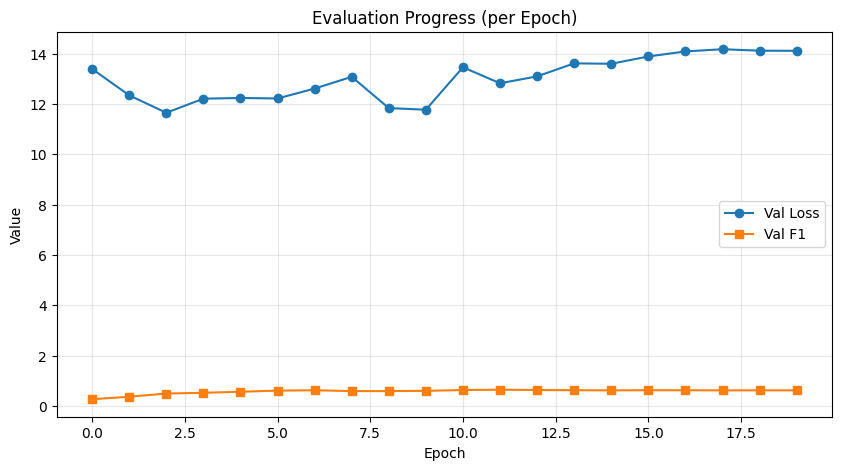

In [13]:
# Training history visualization

# 2. Setup the plot
plot_training_history(results)

## Model Validation & Checkpoint Selection (Dev Set)

In [14]:

# 1. Load the original base model (pristine weights)
best_model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")
# 2. Add the LoRA
adapter_path = DATA_DIR / "models" / experiment_name / "best"
best_model.load_adapter(adapter_path)
# 3. Ready for inference
logger.info("Adapter loaded.")

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first
2026-05-19 06:39:13,022 [INFO]: Adapter loaded. (__main__:7)


## Inference Threshold Calibration
We determine the optimal confidence threshold using the Validation Set to maximize the F1-score.

2026-05-19 06:39:13,031 [INFO]: Finding optimal threshold on validation set (32 samples)... (__main__:16)
2026-05-19 06:39:13,033 [INFO]: Evaluating threshold: 0.4... (__main__:19)
2026-05-19 06:53:16,587 [INFO]: 
>>> EVAL Micro-F1: 0.6416 | Precision: 0.6267 | Recall: 0.6573 (archaeo_ner_greek.training_utils:453)
2026-05-19 06:53:16,589 [INFO]: Evaluating threshold: 0.5... (__main__:19)
2026-05-19 07:07:10,633 [INFO]: 
>>> EVAL Micro-F1: 0.6505 | Precision: 0.6438 | Recall: 0.6573 (archaeo_ner_greek.training_utils:453)
2026-05-19 07:07:10,635 [INFO]: Evaluating threshold: 0.6... (__main__:19)
2026-05-19 07:20:58,402 [INFO]: 
>>> EVAL Micro-F1: 0.6429 | Precision: 0.6569 | Recall: 0.6294 (archaeo_ner_greek.training_utils:453)
2026-05-19 07:20:58,403 [INFO]: Evaluating threshold: 0.7... (__main__:19)
2026-05-19 07:35:04,197 [INFO]: 
>>> EVAL Micro-F1: 0.6447 | Precision: 0.6769 | Recall: 0.6154 (archaeo_ner_greek.training_utils:453)
2026-05-19 07:35:04,198 [INFO]: Evaluating threshold: 

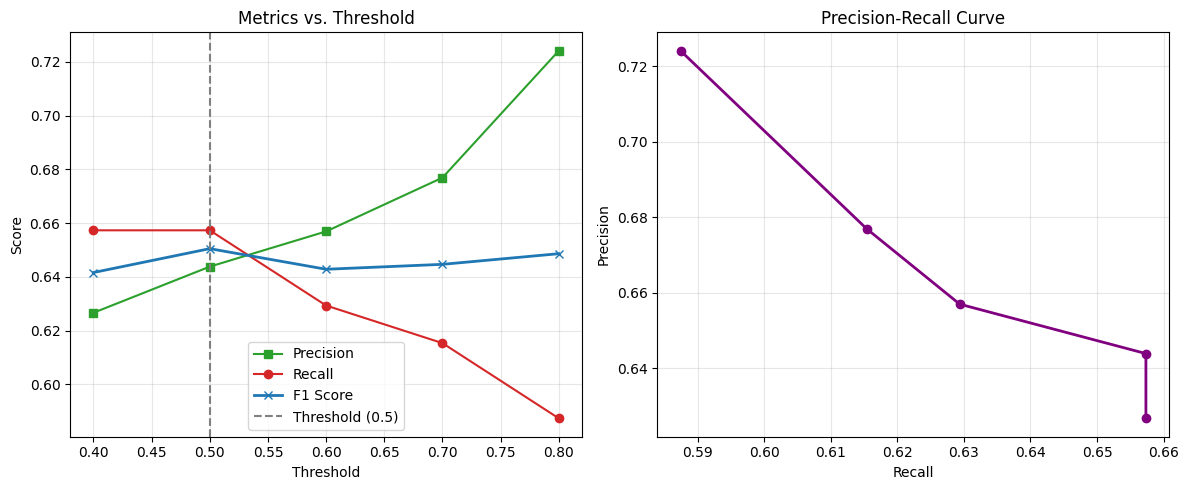

In [15]:
# 1. Prepare data once
val_data_formatted = [
    (ex.text, {"entities": ex.entities, "entity_descriptions": ex.entity_descriptions})
    for ex in val_split
]

# 2. Iterate through thresholds to find the best F1
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]
p_scores = []
r_scores = []
f1_scores = []

best_threshold = 0.5
best_val_f1 = 0

logger.info(f"Finding optimal threshold on validation set ({len(val_split)} samples)...")

for t in thresholds:
    logger.info(f"Evaluating threshold: {t}...")
    res = compute_metrics(best_model, val_data_formatted, threshold=t)
    p_scores.append(res['precision'])
    r_scores.append(res['recall'])
    f1_scores.append(res['f1'])

    if res['f1'] > best_val_f1:
        best_val_f1 = res['f1']
        best_threshold = t

logger.info(f">>> Optimal Threshold Found: {best_threshold} (Val F1: {best_val_f1:.4f})")

# 3. Visualization of the search space
plot_threshold_curves(thresholds, p_scores, r_scores, f1_scores, best_threshold)

## Zero-Shot Performance Baseline
Comparative evaluation of the base model's zero-shot capabilities prior to domain adaptation.

In [16]:
logger.info("Evaluating Zero-Shot Baseline...")
# Load fresh base model without adapters
zero_shot_model = GLiNER2.from_pretrained("fastino/gliner2-multi-v1")
zero_shot_model.to(best_model.device)

# Prepare test data
test_data_formatted = [
    (ex.text, {"entities": ex.entities, "entity_descriptions": ex.entity_descriptions})
    for ex in test_split
]

# Evaluate at a standard threshold (0.5)
zs_results = compute_metrics(zero_shot_model, test_data_formatted, threshold=0.5)

logger.info("\n" + "="*40)
logger.info("ZERO-SHOT BASELINE RESULTS")
logger.info(f"F1 Score : {zs_results['f1']:.4f}")
logger.info(f"Precision: {zs_results['precision']:.4f}")
logger.info(f"Recall   : {zs_results['recall']:.4f}")
logger.info("="*40)

# Log to WandB
log_to_wandb(zs_results, prefix="zero_shot_")

2026-05-19 07:48:57,670 [INFO]: Evaluating Zero-Shot Baseline... (__main__:1)
🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first
2026-05-19 08:02:21,187 [INFO]: 
>>> EVAL Micro-F1: 0.3464 | Precision: 0.5082 | Recall: 0.2627 (archaeo_ner_greek.training_utils:453)
2026-05-19 08:02:21,189 [INFO]: 
======================================== (__main__:15)
2026-05-19 08:02:21,191 [INFO]: ZERO-SHOT BASELINE RESULTS (__main__:16)
2026-05-19 08:02:21,192 [INFO]: F1 Score : 0.3464 (__main__:17)
2026-05-19 08:02:21,193 [INFO]: Precision: 0.5082 (__main__:18)
2026-05-19 08:02:21,195 [INFO]: Recall   : 0.2627 (__main__:19)
2026-05-19 08:02:21,196 [INFO]: ======================================== (__main__:20)


2026-05-19 08:02:27,481 [INFO]: WandB: New run initialized: https://wandb.ai/staalexandropoulou-national-and-kapodistrian-university-/archaeo-ner-greek/runs/vdssthe1 (archaeo_ner_greek.training_utils:583)


## Final Benchmarking on Isolated Gold Test Set
Evaluation of the optimized adapter using the calibrated inference threshold.

In [17]:
# Use the isolated test set created during the grouped split
test_dataset = test_split
test_data_formatted = [
    (ex.text, {"entities": ex.entities, "entity_descriptions": ex.entity_descriptions})
    for ex in test_dataset
]

logger.info(f"Started evaluating model on GOLD TEST SET using optimal threshold: {best_threshold}")
final_results = evaluate_adapter(best_model, adapter_path, test_dataset, threshold=best_threshold)
logger.info(f"Done evaluating model.")

# Log final benchmark to WandB
log_to_wandb(final_results, prefix="gold_test_")

# Upload Best Adapter as Artifact
upload_wandb_artifact(wandb_enabled, adapter_path, experiment_name)

if wandb_enabled:
    wandb.finish()

2026-05-19 08:02:27,502 [INFO]: Started evaluating model on GOLD TEST SET using optimal threshold: 0.5 (__main__:8)
2026-05-19 08:02:27,503 [INFO]: Loading adapter from: /content/archaeo-ner-greek/archaeo-ner-greek/data/models/gliner2_archaeo_lora_20260519_0542/best (archaeo_ner_greek.training_utils:467)
2026-05-19 08:16:02,912 [INFO]: 
>>> EVAL Micro-F1: 0.6491 | Precision: 0.6727 | Recall: 0.6271 (archaeo_ner_greek.training_utils:453)
2026-05-19 08:16:02,915 [INFO]: 
--- EVALUATION RESULTS (best) threshold: 0.5 --- (archaeo_ner_greek.training_utils:477)
2026-05-19 08:16:02,918 [INFO]: F1 Score : 0.6491 (archaeo_ner_greek.training_utils:478)
2026-05-19 08:16:02,920 [INFO]: Precision: 0.6727 (archaeo_ner_greek.training_utils:479)
2026-05-19 08:16:02,922 [INFO]: Recall   : 0.6271 (archaeo_ner_greek.training_utils:480)
2026-05-19 08:16:02,924 [INFO]: Counts   : TP=74, FP=36, FN=44 (archaeo_ner_greek.training_utils:481)
2026-05-19 08:16:02,927 [INFO]: Done evaluating model. (__main__:10)


wandb: Adding directory to artifact (/content/archaeo-ner-greek/archaeo-ner-greek/data/models/gliner2_archaeo_lora_20260519_0542/best)... Done. 0.0s


2026-05-19 08:16:03,935 [INFO]: Adapter successfully uploaded to WandB: adapter-gliner2_archaeo_lora_20260519_0542 (archaeo_ner_greek.training_utils:632)


gold_test_f1,▁
gold_test_fn,▁
gold_test_fp,▁
gold_test_precision,▁
gold_test_recall,▁
gold_test_tp,▁
zero_shot_f1,▁
zero_shot_fn,▁
zero_shot_fp,▁
zero_shot_precision,▁
+2,...


## Granular Performance Metrics by Entity Class
Precision, Recall, and F1-score disaggregated by archaeological entity types.

In [18]:
show_detailed_report(best_model, test_data_formatted, threshold=best_threshold)

2026-05-19 08:31:17,626 [INFO]: 
>>> EVAL Micro-F1: 0.6491 | Precision: 0.6727 | Recall: 0.6271 (archaeo_ner_greek.training_utils:453)


,Entity Type,Precision,Recall,F1-Score,Support
0,🏛️ LOCATION,0.667,1.000,0.800,4
1,🧱 MATERIAL,0.857,0.750,0.800,8
2,📜 CONTEXT,0.787,0.712,0.747,52
3,👤 PERSON,0.800,0.667,0.727,12
4,🏺 ARTEFACT,0.500,0.667,0.571,12
5,⏳ PERIOD,0.500,0.625,0.556,8
6,🧬 SPECIES,1.000,0.333,0.500,3
7,🗺️ FEATURE,0.385,0.263,0.312,19
8,📊 OVERALL (Micro),0.673,0.627,0.649,118


## Categorical Confusion Analysis

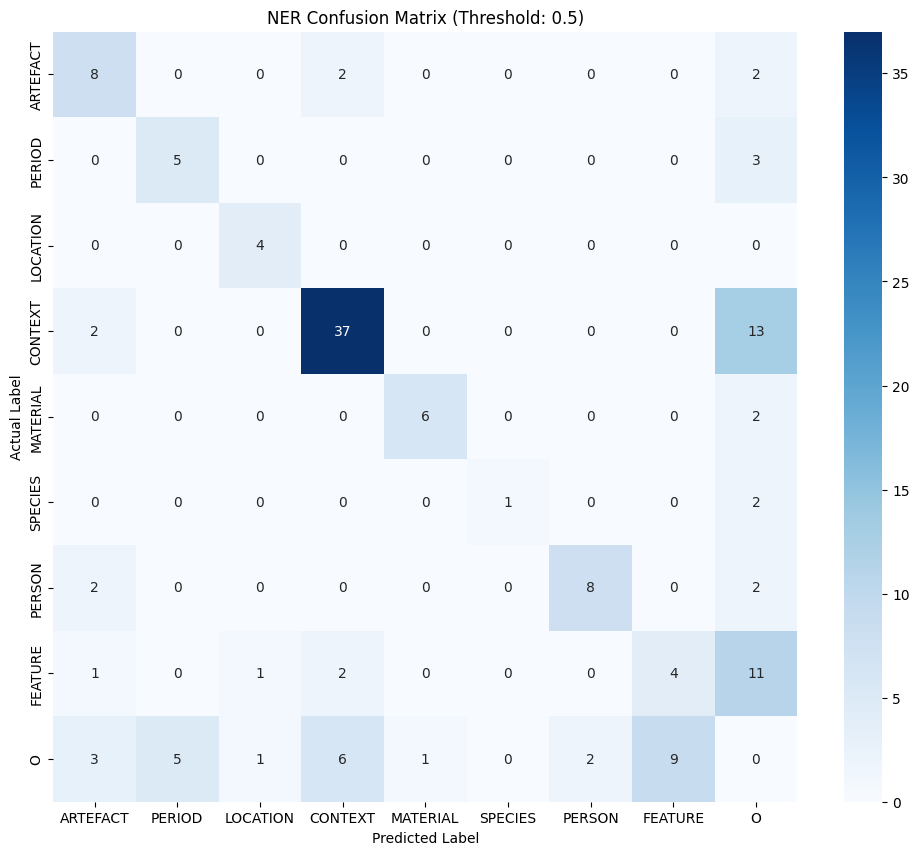

In [19]:
# Plot confusion matrix using the optimized threshold
plot_ner_confusion_matrix(best_model, test_data_formatted, entity_descriptions, threshold=best_threshold)



### Confusion Matrix Interpretation Guide

*   **Diagonal Cells**: True Positives (TP). Correct entity and correct label.
*   **"O" Row (Bottom)**: False Positives (FP). The model hallucinated an entity where none existed.
*   **"O" Column (Right)**: False Negatives (FN). The model completely missed a ground-truth entity.
*   **Off-Diagonal (Non-"O")**: Label Misclassification. The model found the correct text span but assigned the wrong category (e.g., predicted `CONTEXT` for an `ARTEFACT`).


Run error analysis using the optimized threshold
show_error_analysis(best_model, test_data_formatted, entity_descriptions, threshold=best_threshold, num_examples=50)

Final evaluation completed. Best model adapter is persisted locally and uploaded as a WandB artifact.

# Usage & Documentation Guide

This pipeline is designed for both local execution and cloud-based experimentation via Colab.

### 1. Local Environment Configuration
To maintain a stable and reproducible environment, we use `uv` package manager.
*   **Synchronization**: Ensure all dependencies and the local package are installed by running `uv sync` in the root directory.
*   **Notebook Serialization**: If you are working directly with the `.py` source, you can regenerate the interactive notebook using Jupytext:
    ```bash
    uv run jupytext --to ipynb notebooks/gliner2_training.py
    ```
*   **Execution**: The script can be executed via VS Code, Antigravity, or any Jupyter-compatible IDE. Ensure the `.venv` kernel is selected.

### 2. Colab Integration
The script features automatic environment detection and will trigger `setup_colab()` when running in the cloud.
*   **Secrets Management**: Before execution, populate the following keys in the Colab "Secrets" sidebar:
    *   `GITHUB_TOKEN`: Required for cloning the private repository.
    *   `HF_TOKEN`: Required for dataset access.
    *   `HF_REPO_ID`: (Optional) Target dataset repository.
    *   `WANDB_API_KEY`: Enables remote experiment tracking.
*   **Hardware Selection**: For fine-tuning performance, select a GPU or TPU runtime.

### 3. Experiment Tracking (Weights & Biases)
This project leverages WandB for real-time experiment tracking and artifact persistence.
*   **Metrics**: Training loss, validation metrics, and convergence curves are synchronized automatically.
*   **Artifact Persistence**: The optimized LoRA adapter is uploaded as a versioned artifact at the conclusion of the run. This provides a cloud-based backup and ensures the best model state is never lost.
*   **Comparative Baseline**: The dashboard includes both zero-shot and fine-tuned results to facilitate objective performance analysis.

### 4. Reproducibility & Artifacts
*   **Local Storage**: Check the `data/models/{experiment_name}` directory for the best-performing adapter and local manifests.
*   **Split Integrity (Leakage Prevention)**: The `split_manifest.json` preserves the exact document-grouped partitions used during the session. In archaeological texts, sentences from the same document often share localized terminology and context. Splitting a single document across partitions would cause "data leakage," leading to inflated, unrealistic performance metrics. Maintaining this manifest ensures that the evaluation is conducted on entirely "unseen" documents. This provides an audit trail ensuring the model's performance is based on learning rather than memorization on specific document.

extra error analysis

In [22]:
def show_error_analysis_custom(
    model,
    dataset,
    entity_descriptions,
    threshold=0.8,
    num_examples=5
):
    """
    Qualitative error analysis for GLiNER2.

    Compares gold entities and predicted entities using exact text + label matching.
    Prints:
    - True Positives (TPs)
    - False Positives (FPs)
    - False Negatives (FNs)
    """

    print(f"--- QUALITATIVE ERROR ANALYSIS (Threshold: {threshold}) ---\n")

    # Safety check
    if dataset is None or len(dataset) == 0:
        print("Dataset is empty. No examples to analyze.")
        return

    for i, ex in enumerate(dataset[:num_examples]):

        # Expected format:
        # ex = (text, {"entities": ..., "entity_descriptions": ...})
        text = ex[0]
        gt_entities = ex[1]["entities"]

        # 1. Get predictions
        output = model.extract_entities(
            text,
            entity_descriptions,
            threshold=threshold
        )

        pred_entities = output.get("entities", {})

        # 2. Flatten gold entities
        gt_spans = [
            (entity_text, label)
            for label, entity_texts in gt_entities.items()
            for entity_text in entity_texts
        ]

        # 3. Flatten predicted entities
        pred_spans = [
            (entity_text, label)
            for label, entity_texts in pred_entities.items()
            for entity_text in entity_texts
        ]

        # 4. Categorize
        tp = [p for p in pred_spans if p in gt_spans]
        fp = [p for p in pred_spans if p not in gt_spans]
        fn = [g for g in gt_spans if g not in pred_spans]

        # 5. Display
        print(f"EXAMPLE {i + 1}:")
        print(f"TEXT: {text[:150]}...")

        if tp:
            print(f"  [TPs]: {tp}")

        if fp:
            print(f"  \033[91m[FPs]: {fp}\033[0m")  # Red

        if fn:
            print(f"  \033[93m[FNs]: {fn}\033[0m")  # Yellow

        print("-" * 50)

In [23]:
show_error_analysis_custom(
    best_model,
    test_data_formatted,
    entity_descriptions,
    threshold=best_threshold,
    num_examples=21
)

--- QUALITATIVE ERROR ANALYSIS (Threshold: 0.5) ---

EXAMPLE 1:
TEXT: Ενώτια...
  [TPs]: [('Ενώτια', 'ARTEFACT')]
--------------------------------------------------
EXAMPLE 2:
TEXT: Ζεύγος χρυσών ενωτίων που καταλήγουν σε κεφαλή λέοντα, ο λαιμός με διακόσμηση filligrant (περίκλειστον) και στέλεχος στρεπτό που καταλήγει σε κομβίο....
  [TPs]: [('ενωτίων', 'ARTEFACT'), ('χρυσών', 'MATERIAL'), ('λέοντα', 'SPECIES')]
  [FPs]: [('λαιμός', 'ARTEFACT'), ('filligrant', 'FEATURE'), ('στρεπτό', 'FEATURE')]
  [FNs]: [('περίκλειστον', 'FEATURE'), ('διακόσμηση filligrant', 'FEATURE')]
--------------------------------------------------
EXAMPLE 3:
TEXT: Ο ναός της Ίσιδος εντοπίστηκε στο βόρειο τμήμα του τεμένους....
  [TPs]: [('ναός της Ίσιδος', 'CONTEXT'), ('τεμένους', 'CONTEXT')]
  [FPs]: [('Ίσιδος', 'LOCATION')]
--------------------------------------------------
EXAMPLE 4:
TEXT: Ήταν ορθογώνιο κτίριο διαστάσεων 11,30 x 18,50 μ., με προσανατολισμό Β-Ν....
  [TPs]: [('ορθογώνιο κτίριο', 'CONTEXT')]
